# Star Classification with Multi-Layer Perceptron (MLP)

This notebook implements a star classification system using artificial neural networks. We'll explore different architectures and hyperparameter configurations to optimize our model's performance on the stellar dataset.

## Section 1: Setup, Data Loading, and Exploratory Data Analysis (EDA)

Load the star classification dataset and perform initial data cleaning and visualization.

### 1. Environment Setup
This section imports the required libraries, configures plotting defaults, and suppresses non-critical warnings to keep the output clean.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import RobustScaler

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

### 2. Data Loading and Cleaning
We load the selected columns, enforce numeric types, remove invalid rows, and filter unrealistic sensor values before modeling.

In [2]:
file_path = 'star_classification.csv'

# LOAD DATA
columns_to_load = ['class', 'u', 'g', 'r', 'i', 'z', 'redshift']

df = pd.read_csv(file_path, usecols=columns_to_load)

# 1. Force numeric conversion for any dirty or unreadable strings
for col in columns_to_load[1:]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Remove NaN values generated by previous step
df = df.dropna(subset=columns_to_load[1:])

# 3. PHYSICAL FILTERING: Remove SDSS sensor errors (-9999)
for col in ['u', 'g', 'r', 'i', 'z']:
    df = df[df[col] > -30]

print(f"Clean dataset! Remaining rows: {len(df)}")

# Styled preview for cleaner notebook visualization
preview = (
    df.head()
    .style
    .hide(axis='index')
    .format({
        'u': '{:.3f}', 'g': '{:.3f}', 'r': '{:.3f}',
        'i': '{:.3f}', 'z': '{:.3f}', 'redshift': '{:.5f}'
    })
    .set_caption('First 5 Rows (Cleaned Data)')
    .set_properties(**{'text-align': 'center', 'padding': '6px'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#1f2937')]},
        {'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white')]},
        {'selector': 'td', 'props': [('border', '1px solid #d1d5db')]},
    ])
)
display(preview)

Clean dataset! Remaining rows: 99999


u,g,r,i,z,class,redshift
23.879,22.275,20.395,19.166,18.794,GALAXY,0.63479
24.778,22.832,22.584,21.168,21.614,GALAXY,0.77914
25.263,22.664,20.610,19.349,18.948,GALAXY,0.64419
22.137,23.777,21.612,20.505,19.250,GALAXY,0.93235
19.437,17.580,16.497,15.977,15.545,GALAXY,0.11612


### 3. Exploratory Data Analysis
Here we inspect class balance and feature distributions to understand skewness, outliers, and potential modeling challenges.

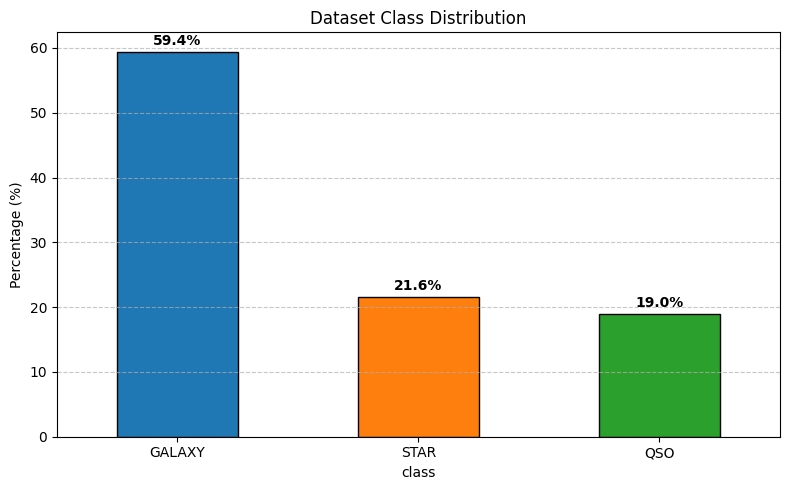

In [3]:
# PREPROCESSING AND EDA
y = df['class']
X = df.drop('class', axis=1)

# VISUAL EXPLORATION OF CLASS DISTRIBUTION
class_counts = y.value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
plt.title('Dataset Class Distribution')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(class_counts):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

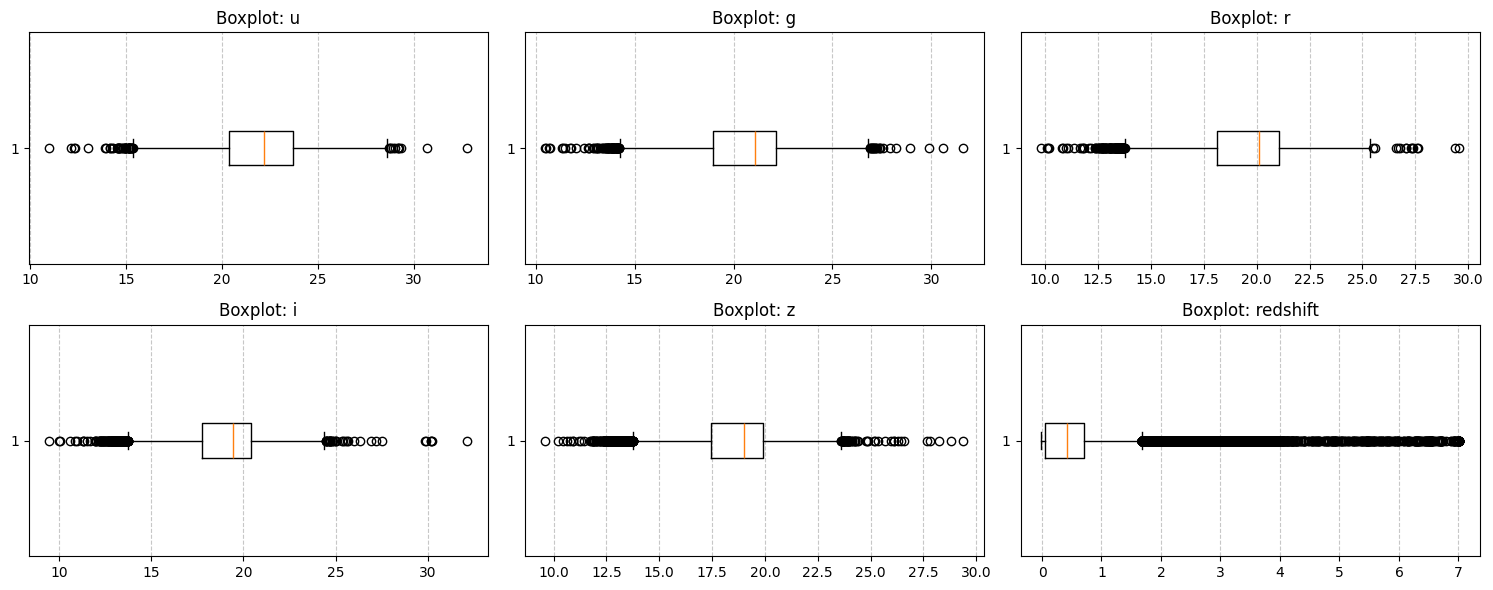

In [4]:
# VISUAL EXPLORATION OF OUTLIERS (BOXPLOTS)
plt.figure(figsize=(15, 6))
for i, col in enumerate(columns_to_load[1:], 1):
    plt.subplot(2, 3, i)
    plt.boxplot(X[col].dropna(), vert=False)
    plt.title(f'Boxplot: {col}')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

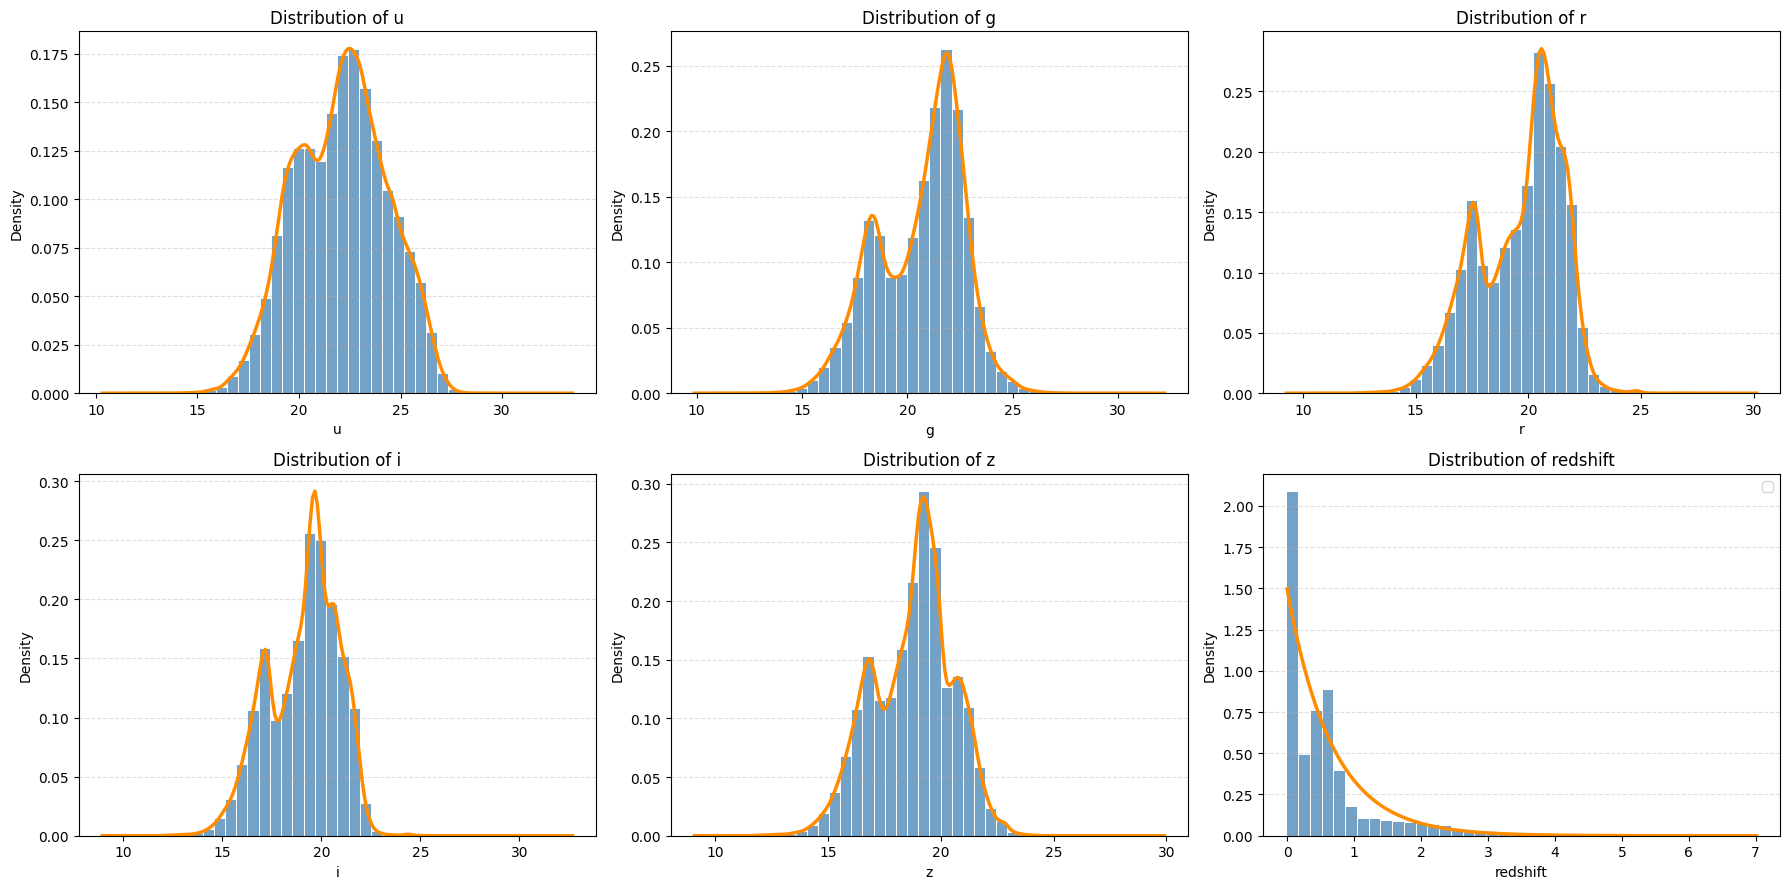

In [5]:
# Distribution visualization for all numeric variables with exponential fit only for redshift
import seaborn as sns
from scipy.stats import expon

numeric_columns = columns_to_load[1:]  # ['u', 'g', 'r', 'i', 'z', 'redshift']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    # Histogram in blue
    sns.histplot(
        data=df,
        x=col,
        bins=40,
        stat='density',
        color='steelblue',
        edgecolor='white',
        alpha=0.75,
        ax=axes[i]
    )

    if col == 'redshift':
        redshift_data = df[col].dropna()
        redshift_data = redshift_data[redshift_data >= 0]

        if len(redshift_data) > 1:
            loc, scale = expon.fit(redshift_data, floc=0)
            x_fit = np.linspace(redshift_data.min(), redshift_data.max(), 400)
            y_fit = expon.pdf(x_fit, loc=loc, scale=scale)
            axes[i].plot(x_fit, y_fit, color='darkorange', linewidth=2.5)
            axes[i].legend()
    else:
        sns.kdeplot(
            data=df,
            x=col,
            color='darkorange',
            linewidth=2.5,
            ax=axes[i]
        )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Section 2: Baseline Modeling
We split the dataset into train/validation/test sets and run a compact hyperparameter search to select a baseline MLP configuration.

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

learning_rates = [0.2, 0.1, 0.01]
hidden_layer_configs = [(1,), (2,), (4,)]

best_accuracy_val = 0
best_params = {}
best_model = None

print("\nStarting optimization on Validation Set ...\n")

for lr in learning_rates:
    for hl in hidden_layer_configs:
        
        mlp = MLPClassifier(
            hidden_layer_sizes=hl,
            activation='logistic',
            solver='sgd',
            batch_size=128, 
            learning_rate_init=lr,
            max_iter=500,
            random_state=42
        )
        
        mlp.fit(X_train_scaled, y_train)
        accuracy_val = mlp.score(X_val_scaled, y_val)
        
        print(f"LR: {lr} | Neurons: {hl[0]:02d} | Validation Accuracy: {accuracy_val:.5f}")
        
        if accuracy_val > best_accuracy_val:
            best_accuracy_val = accuracy_val
            best_params = {'learning_rate_init': lr, 'hidden_layer_sizes': hl}
            best_model = mlp

print("\n--- Optimization Results ---")
print(f"Best parameters found: {best_params}")
print(f"Best validation accuracy: {best_accuracy_val:.5f}")


Starting optimization on Validation Set (Full-Batch Gradient Descent)...

LR: 0.2 | Neurons: 01 | Validation Accuracy: 0.78250
LR: 0.2 | Neurons: 02 | Validation Accuracy: 0.96535
LR: 0.2 | Neurons: 04 | Validation Accuracy: 0.96920
LR: 0.1 | Neurons: 01 | Validation Accuracy: 0.78110
LR: 0.1 | Neurons: 02 | Validation Accuracy: 0.96330
LR: 0.1 | Neurons: 04 | Validation Accuracy: 0.96670
LR: 0.01 | Neurons: 01 | Validation Accuracy: 0.77870
LR: 0.01 | Neurons: 02 | Validation Accuracy: 0.96230
LR: 0.01 | Neurons: 04 | Validation Accuracy: 0.96480

--- Optimization Results ---
Best parameters found: {'learning_rate_init': 0.2, 'hidden_layer_sizes': (4,)}
Best validation accuracy: 0.96920


### Baseline Error Analysis
Using the selected baseline model, we compare train and test performance, then inspect class-wise metrics and the confusion matrix.


--- Overfitting Check (Train vs Test) ---
Train accuracy: 0.9683
Test accuracy : 0.9705
Gap (train - test): -0.0022
Interpretation: No clear overfitting signal (small train-test gap).

--- Classification Report ---
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98     11889
         QSO       0.96      0.92      0.94      3792
        STAR       0.97      1.00      0.99      4319

    accuracy                           0.97     20000
   macro avg       0.97      0.96      0.97     20000
weighted avg       0.97      0.97      0.97     20000



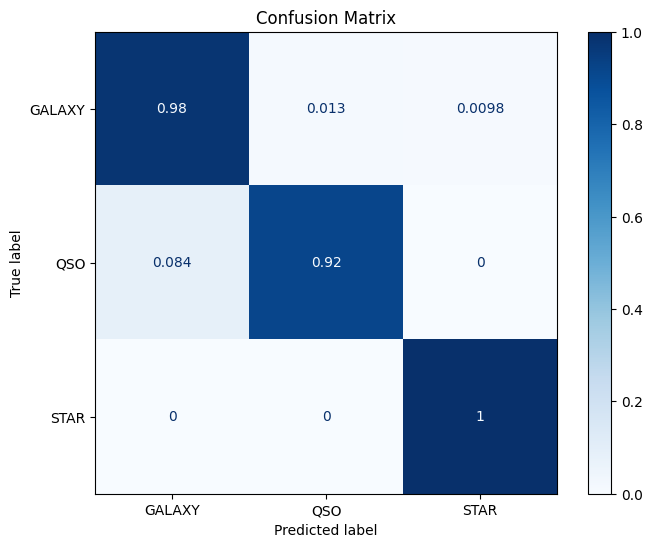

In [7]:
# Train vs Test comparison to check overfitting
accuracy_train = best_model.score(X_train_scaled, y_train)
accuracy_test = best_model.score(X_test_scaled, y_test)
train_test_gap = accuracy_train - accuracy_test

print("\n--- Overfitting Check (Train vs Test) ---")
print(f"Train accuracy: {accuracy_train:.4f}")
print(f"Test accuracy : {accuracy_test:.4f}")
print(f"Gap (train - test): {train_test_gap:.4f}")

if train_test_gap <= 0.02:
    print("Interpretation: No clear overfitting signal (small train-test gap).")
else:
    print("Interpretation: Potential overfitting (train-test gap is relatively large).")

# ERROR ANALYSIS FOR EACH CLASS
y_pred = best_model.predict(X_test_scaled)

print("\n--- Classification Report ---")
# Report shows precision, recall and f1-score for each class, allowing error rate isolation
print(classification_report(y_test, y_pred))

# Confusion matrix visualization to see specific false positives/negatives between classes
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix')
plt.show()

## Section 3: Stability with Respect to Train Size
This experiment evaluates how validation and test accuracy evolve when the training fraction is reduced while keeping validation fixed.

Train:  60.0% | Validation: 20.0% | Test:  20.0% | Val Acc: 0.97050 | Test Acc: 0.96920
Train:  50.0% | Validation: 20.0% | Test:  30.0% | Val Acc: 0.96945 | Test Acc: 0.96720
Train:  40.0% | Validation: 20.0% | Test:  40.0% | Val Acc: 0.97000 | Test Acc: 0.96772
Train:  30.0% | Validation: 20.0% | Test:  50.0% | Val Acc: 0.96935 | Test Acc: 0.96796
Train:  20.0% | Validation: 20.0% | Test:  60.0% | Val Acc: 0.96830 | Test Acc: 0.96690
Train:  10.0% | Validation: 20.0% | Test:  70.0% | Val Acc: 0.96695 | Test Acc: 0.96521
Train:   2.0% | Validation: 20.0% | Test:  78.0% | Val Acc: 0.96560 | Test Acc: 0.96404
Train:   1.0% | Validation: 20.0% | Test:  79.0% | Val Acc: 0.95805 | Test Acc: 0.95637


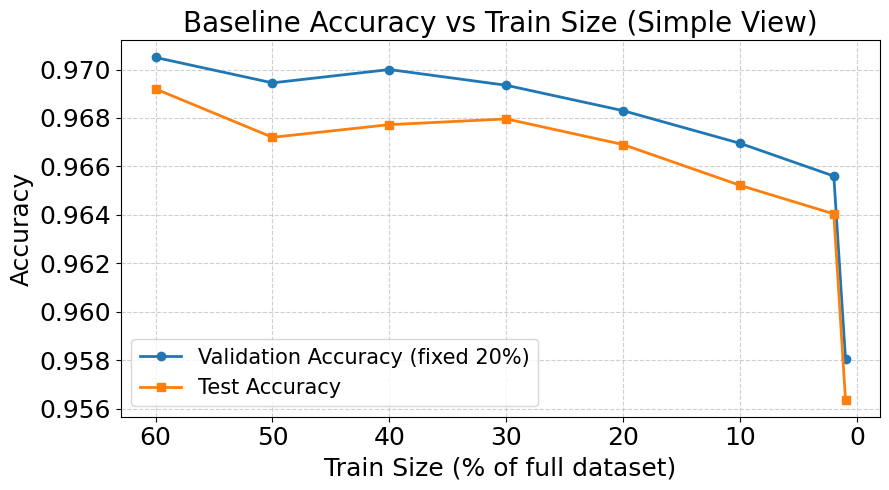

In [8]:
# Baseline sensitivity (simple view)
# Fixed validation at 20%, varying train-test split

train_fractions_total = [0.60, 0.50, 0.40, 0.30, 0.20, 0.10, 0.02, 0.01]

# Baseline feature set (includes redshift)
X_base = df.drop('class', axis=1)
y_base = df['class']

# Keep validation fixed at 20%
X_rem, X_val_fixed, y_rem, y_val_fixed = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)

# Reuse best baseline params if available; otherwise fallback defaults
baseline_lr = 0.1
baseline_hidden = (4,)
if 'best_params' in globals() and isinstance(best_params, dict):
    baseline_lr = best_params.get('learning_rate_init', baseline_lr)
    baseline_hidden = best_params.get('hidden_layer_sizes', baseline_hidden)

train_sizes_pct = []
val_accuracies = []
test_accuracies = []

for train_frac_total in train_fractions_total:
    rel_train_in_remaining = train_frac_total / 0.8

    X_train_sub, X_test_var, y_train_sub, y_test_var = train_test_split(
        X_rem,
        y_rem,
        train_size=rel_train_in_remaining,
        random_state=42,
        stratify=y_rem
    )

    scaler_frac = RobustScaler()
    X_train_sub_scaled = scaler_frac.fit_transform(X_train_sub)
    X_val_fixed_scaled = scaler_frac.transform(X_val_fixed)
    X_test_var_scaled = scaler_frac.transform(X_test_var)

    model_frac = MLPClassifier(
        hidden_layer_sizes=baseline_hidden,
        activation='logistic',
        solver='sgd',
        batch_size=128,
        learning_rate_init=baseline_lr,
        max_iter=500,
        random_state=42
    )

    model_frac.fit(X_train_sub_scaled, y_train_sub)
    acc_val = model_frac.score(X_val_fixed_scaled, y_val_fixed)
    acc_test = model_frac.score(X_test_var_scaled, y_test_var)

    train_sizes_pct.append(100 * train_frac_total)
    val_accuracies.append(acc_val)
    test_accuracies.append(acc_test)

    print(
        f"Train: {100*train_frac_total:5.1f}% | Validation: 20.0% | "
        f"Test: {100*(0.8-train_frac_total):5.1f}% | Val Acc: {acc_val:.5f} | Test Acc: {acc_test:.5f}"
    )

# Simple plot to show accuracies are very stable
plt.figure(figsize=(9, 5))
plt.plot(train_sizes_pct, val_accuracies, marker='o', linewidth=2, label='Validation Accuracy (fixed 20%)')
plt.plot(train_sizes_pct, test_accuracies, marker='s', linewidth=2, label='Test Accuracy')
plt.gca().invert_xaxis()  # left -> right: from 60% down to 1%
plt.title('Baseline Accuracy vs Train Size (Simple View)', fontsize=20)
plt.xlabel('Train Size (% of full dataset)', fontsize=18)
plt.ylabel('Accuracy', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [9]:
# Reusable feature sets for controlled experiments
y_target = df['class']
X_with_redshift = df.drop('class', axis=1)
X_no_redshift = df.drop(['class', 'redshift'], axis=1)

## Section 4: Additional Experiments
The next blocks repeat the same training protocol under different feature sets and split constraints to compare behavior under controlled changes.

### Experiment A: Extreme Split with Redshift
We keep all baseline features, including redshift, and evaluate performance under an intentionally tiny training subset.


Starting optimization on Validation Set (Full-Batch Gradient Descent)...

LR: 0.2 | Neurons: 04 | Validation Accuracy: 0.96045

--- Optimization Results ---
Best parameters found: {'learning_rate_init': 0.2, 'hidden_layer_sizes': (4,)}
Best validation accuracy: 0.96045

Final accuracy on Test Set (unseen data): 0.9551

--- Classification Report ---
              precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96     46962
         QSO       0.95      0.88      0.92     14980
        STAR       0.95      0.99      0.97     17059

    accuracy                           0.96     79001
   macro avg       0.95      0.95      0.95     79001
weighted avg       0.96      0.96      0.95     79001



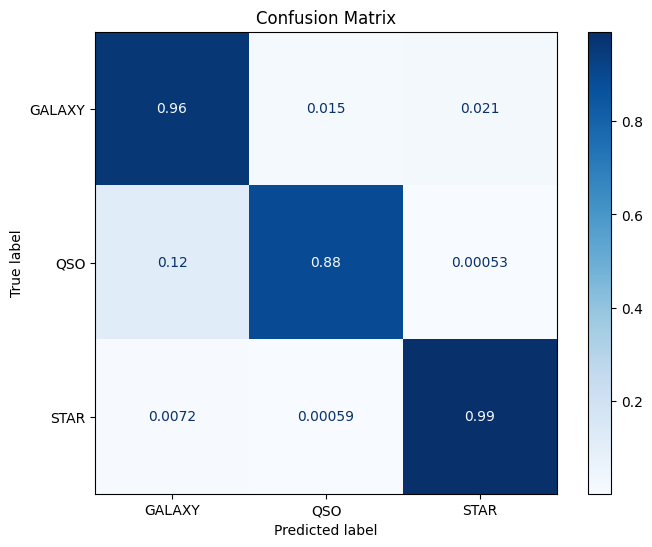

In [ ]:
# HOLD-OUT METHOD - Testing with minimal training data
X_train, X_temp, y_train, y_temp = train_test_split(
    X_with_redshift, y_target, test_size=0.99, random_state=42, stratify=y_target
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.79798, random_state=42, stratify=y_temp
)

# Use RobustScaler to mitigate the effect of outliers on the distribution tails
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# HYPERPARAMETER SEARCH (GRID SEARCH) ON VALIDATION SET
learning_rates = [0.2]
hidden_layer_configs = [(4,)]

best_accuracy_val = 0
best_params = {}
best_model = None

print("\nStarting optimization on Validation Set...\n")

for lr in learning_rates:
    for hl in hidden_layer_configs:
        
        mlp = MLPClassifier(
            hidden_layer_sizes=hl,
            activation='logistic',
            solver='sgd',
            batch_size=128, 
            learning_rate_init=lr,
            max_iter=500,
            random_state=42
        )
        
        mlp.fit(X_train_scaled, y_train)
        accuracy_val = mlp.score(X_val_scaled, y_val)
        
        print(f"LR: {lr} | Neurons: {hl[0]:02d} | Validation Accuracy: {accuracy_val:.5f}")
        
        if accuracy_val > best_accuracy_val:
            best_accuracy_val = accuracy_val
            best_params = {'learning_rate_init': lr, 'hidden_layer_sizes': hl}
            best_model = mlp

print("\n--- Optimization Results ---")
print(f"Best parameters found: {best_params}")
print(f"Best validation accuracy: {best_accuracy_val:.5f}")

# FINAL EVALUATION ON TEST SET
accuracy_test = best_model.score(X_test_scaled, y_test)
print(f"\nFinal accuracy on Test Set (unseen data): {accuracy_test:.4f}")

# ERROR ANALYSIS FOR EACH CLASS
y_pred = best_model.predict(X_test_scaled)

print("\n--- Classification Report ---")
# Report shows precision, recall and f1-score for each class, allowing error rate isolation
print(classification_report(y_test, y_pred))

# Confusion matrix visualization to see specific false positives/negatives between classes
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix')
plt.show()

### Experiment B: No-Redshift Baseline
This variant removes redshift and reuses the same validation protocol to isolate the impact of that feature.


Starting optimization on Validation Set (Full-Batch Gradient Descent)...

LR: 0.2 | Neurons: 01 | Validation Accuracy: 0.74000
LR: 0.2 | Neurons: 02 | Validation Accuracy: 0.81155
LR: 0.2 | Neurons: 04 | Validation Accuracy: 0.83675
LR: 0.1 | Neurons: 01 | Validation Accuracy: 0.74065
LR: 0.1 | Neurons: 02 | Validation Accuracy: 0.80535
LR: 0.1 | Neurons: 04 | Validation Accuracy: 0.83525
LR: 0.01 | Neurons: 01 | Validation Accuracy: 0.73990
LR: 0.01 | Neurons: 02 | Validation Accuracy: 0.80355
LR: 0.01 | Neurons: 04 | Validation Accuracy: 0.83240

--- Optimization Results ---
Best parameters found: {'learning_rate_init': 0.2, 'hidden_layer_sizes': (4,)}
Best validation accuracy: 0.83675

Final accuracy on Test Set (unseen data): 0.8336

--- Classification Report ---
              precision    recall  f1-score   support

      GALAXY       0.88      0.93      0.90     11889
         QSO       0.77      0.73      0.75      3792
        STAR       0.74      0.66      0.70      4319

   

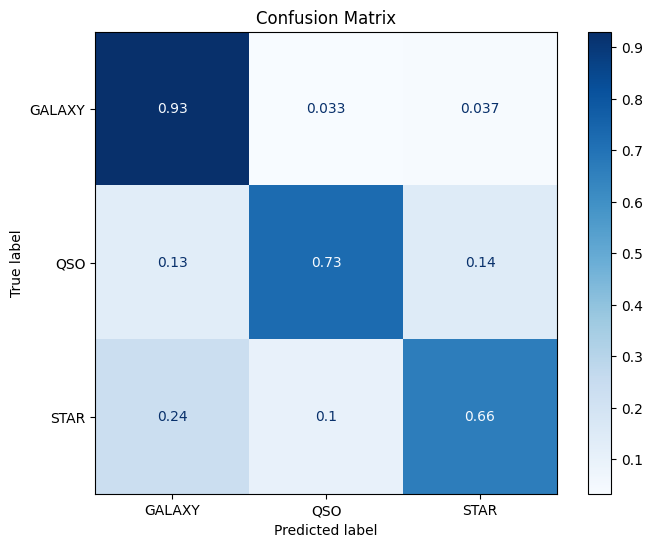

In [ ]:
# HOLD-OUT METHOD (Train, Validation, Test) without redshift
X_temp, X_test, y_temp, y_test = train_test_split(
    X_no_redshift, y_target, test_size=0.2, random_state=42, stratify=y_target
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Use RobustScaler to mitigate the effect of outliers on the distribution tails
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# HYPERPARAMETER SEARCH (GRID SEARCH) ON VALIDATION SET
learning_rates = [0.2, 0.1, 0.01]
hidden_layer_configs = [(1,), (2,), (4,)]

best_accuracy_val = 0
best_params = {}
best_model = None

print("\nStarting optimization on Validation Set ...\n")

for lr in learning_rates:
    for hl in hidden_layer_configs:
        
        mlp = MLPClassifier(
            hidden_layer_sizes=hl,
            activation='logistic',
            solver='sgd',
            batch_size=128, 
            learning_rate_init=lr,
            max_iter=500,
            random_state=42
        )
        
        mlp.fit(X_train_scaled, y_train)
        accuracy_val = mlp.score(X_val_scaled, y_val)
        
        print(f"LR: {lr} | Neurons: {hl[0]:02d} | Validation Accuracy: {accuracy_val:.5f}")
        
        if accuracy_val > best_accuracy_val:
            best_accuracy_val = accuracy_val
            best_params = {'learning_rate_init': lr, 'hidden_layer_sizes': hl}
            best_model = mlp

print("\n--- Optimization Results ---")
print(f"Best parameters found: {best_params}")
print(f"Best validation accuracy: {best_accuracy_val:.5f}")

# FINAL EVALUATION ON TEST SET
accuracy_test = best_model.score(X_test_scaled, y_test)
print(f"\nFinal accuracy on Test Set (unseen data): {accuracy_test:.4f}")

# ERROR ANALYSIS FOR EACH CLASS
y_pred = best_model.predict(X_test_scaled)

print("\n--- Classification Report ---")
# Report shows precision, recall and f1-score for each class, allowing error rate isolation
print(classification_report(y_test, y_pred))

# Confusion matrix visualization to see specific false positives/negatives between classes
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix')
plt.show()

### Experiment C: No-Redshift with Deeper Architecture
We keep the no-redshift setting but increase network depth to compare whether extra capacity recovers performance.


Starting optimization on Validation Set (Full-Batch Gradient Descent)...

LR: 0.2 | Neurons: 32 | Validation Accuracy: 0.88300
LR: 0.1 | Neurons: 32 | Validation Accuracy: 0.87955
LR: 0.01 | Neurons: 32 | Validation Accuracy: 0.59445

--- Optimization Results ---
Best parameters found: {'learning_rate_init': 0.2, 'hidden_layer_sizes': (32, 16, 8, 4)}
Best validation accuracy: 0.88300

Final accuracy on Test Set (unseen data): 0.8790

--- Classification Report ---
              precision    recall  f1-score   support

      GALAXY       0.90      0.95      0.93     11889
         QSO       0.84      0.78      0.81      3792
        STAR       0.84      0.76      0.80      4319

    accuracy                           0.88     20000
   macro avg       0.86      0.83      0.84     20000
weighted avg       0.88      0.88      0.88     20000



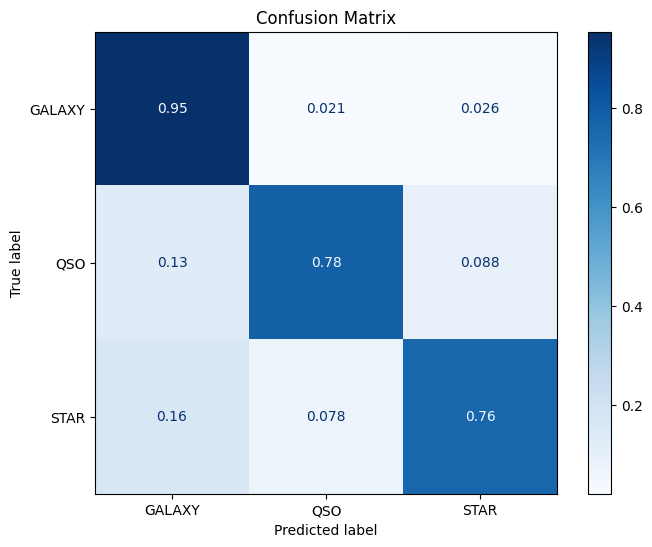

In [ ]:
# HOLD-OUT METHOD (Train, Validation, Test) without redshift
X_temp, X_test, y_temp, y_test = train_test_split(
    X_no_redshift, y_target, test_size=0.2, random_state=42, stratify=y_target
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Use RobustScaler to mitigate the effect of outliers on the distribution tails
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# HYPERPARAMETER SEARCH (GRID SEARCH) ON VALIDATION SET
learning_rates = [0.2, 0.1, 0.01]
hidden_layer_configs = [(32, 16, 8, 4)]

best_accuracy_val = 0
best_params = {}
best_model = None

print("\nStarting optimization on Validation Set...\n")

for lr in learning_rates:
    for hl in hidden_layer_configs:
        
        mlp = MLPClassifier(
            hidden_layer_sizes=hl,
            activation='logistic',
            solver='sgd',
            batch_size=128, 
            learning_rate_init=lr,
            max_iter=500,
            random_state=42
        )
        
        mlp.fit(X_train_scaled, y_train)
        accuracy_val = mlp.score(X_val_scaled, y_val)
        
        print(f"LR: {lr} | Neurons: {hl[0]:02d} | Validation Accuracy: {accuracy_val:.5f}")
        
        if accuracy_val > best_accuracy_val:
            best_accuracy_val = accuracy_val
            best_params = {'learning_rate_init': lr, 'hidden_layer_sizes': hl}
            best_model = mlp

print("\n--- Optimization Results ---")
print(f"Best parameters found: {best_params}")
print(f"Best validation accuracy: {best_accuracy_val:.5f}")

# FINAL EVALUATION ON TEST SET
accuracy_test = best_model.score(X_test_scaled, y_test)
print(f"\nFinal accuracy on Test Set (unseen data): {accuracy_test:.4f}")

# ERROR ANALYSIS FOR EACH CLASS
y_pred = best_model.predict(X_test_scaled)

print("\n--- Classification Report ---")
# Report shows precision, recall and f1-score for each class, allowing error rate isolation
print(classification_report(y_test, y_pred))

# Confusion matrix visualization to see specific false positives/negatives between classes
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix')
plt.show()

### Experiment D: No-Redshift with Extreme Split
Finally, we combine no-redshift features with a minimal-training split to evaluate the most constrained scenario.


Starting optimization on Validation Set (Full-Batch Gradient Descent)...

LR: 0.2 | Neurons: 32 | Validation Accuracy: 0.59398
LR: 0.1 | Neurons: 32 | Validation Accuracy: 0.59398
LR: 0.01 | Neurons: 32 | Validation Accuracy: 0.59398

--- Optimization Results ---
Best parameters found: {'learning_rate_init': 0.2, 'hidden_layer_sizes': (32, 16, 8, 4)}
Best validation accuracy: 0.59398

Final accuracy on Test Set (unseen data): 0.5945

--- Classification Report ---
              precision    recall  f1-score   support

      GALAXY       0.59      1.00      0.75     58851
         QSO       0.00      0.00      0.00     18772
        STAR       0.00      0.00      0.00     21377

    accuracy                           0.59     99000
   macro avg       0.20      0.33      0.25     99000
weighted avg       0.35      0.59      0.44     99000



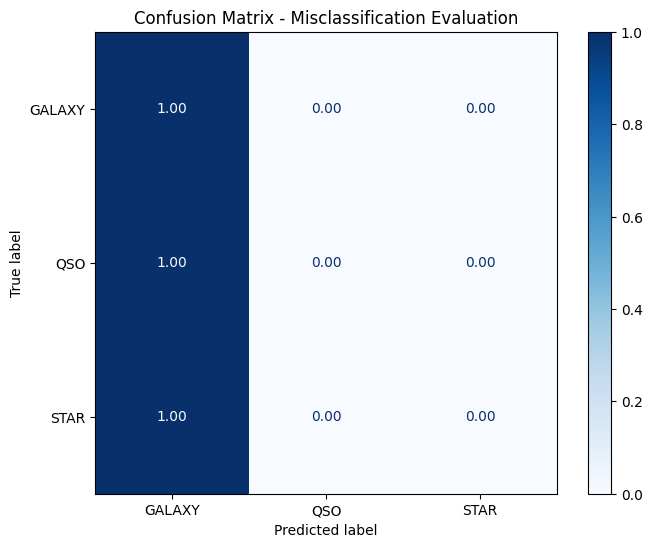

In [ ]:
# HOLD-OUT METHOD - Testing with minimal training data without redshift
X_temp, X_test, y_temp, y_test = train_test_split(
    X_no_redshift, y_target, test_size=0.99, random_state=42, stratify=y_target
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.798, random_state=42, stratify=y_temp
)

# Use RobustScaler to mitigate the effect of outliers on the distribution tails
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# HYPERPARAMETER SEARCH (GRID SEARCH) ON VALIDATION SET
learning_rates = [0.2, 0.1, 0.01]
hidden_layer_configs = [(32, 16, 8, 4)]

best_accuracy_val = 0
best_params = {}
best_model = None

print("\nStarting optimization on Validation Set ...\n")

for lr in learning_rates:
    for hl in hidden_layer_configs:
        
        mlp = MLPClassifier(
            hidden_layer_sizes=hl,
            activation='logistic',
            solver='sgd',
            batch_size=128, 
            learning_rate_init=lr,
            max_iter=500,
            random_state=42
        )
        
        mlp.fit(X_train_scaled, y_train)
        accuracy_val = mlp.score(X_val_scaled, y_val)
        
        print(f"LR: {lr} | Neurons: {hl[0]:02d} | Validation Accuracy: {accuracy_val:.5f}")
        
        if accuracy_val > best_accuracy_val:
            best_accuracy_val = accuracy_val
            best_params = {'learning_rate_init': lr, 'hidden_layer_sizes': hl}
            best_model = mlp

print("\n--- Optimization Results ---")
print(f"Best parameters found: {best_params}")
print(f"Best validation accuracy: {best_accuracy_val:.5f}")

# FINAL EVALUATION ON TEST SET
accuracy_test = best_model.score(X_test_scaled, y_test)
print(f"\nFinal accuracy on Test Set (unseen data): {accuracy_test:.4f}")

# ERROR ANALYSIS FOR EACH CLASS
y_pred = best_model.predict(X_test_scaled)

print("\n--- Classification Report ---")
# Report shows precision, recall and f1-score for each class, allowing error rate isolation
print(classification_report(y_test, y_pred))

# Confusion matrix visualization to see specific false positives/negatives between classes
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='.2f', ax=plt.gca())
plt.title('Confusion Matrix - Misclassification Evaluation')
plt.show()